In [1]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
tokenizer

BertTokenizerFast(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False),  added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}

In [2]:
# !wget https://archive.ics.uci.edu/static/public/176/blood+transfusion+service+center.zip
# !unzip blood+transfusion+service+center.zip

In [3]:
# !unzip census+income.zip

In [4]:
import pandas as pd

df = pd.read_csv('heart.csv')
print(len(df))
df

918


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [5]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [6]:
import numpy as np
import torch

DROP_P = 0.2

def concatenate_text(x_full):
    x = {}
    for i, j in x_full.items():
        x[i] = j if np.random.random() > DROP_P else '[UNK]'

    if x['ChestPainType'] == 'TA':
        pt = 'Typical Angina'
    elif x['ChestPainType'] == 'ATA':
        pt = 'Atypical Angina'
    elif x['ChestPainType'] == 'NAP':
        pt = 'Non-Anginal Pain'
    elif x['ChestPainType'] == 'ASY':
        pt = 'Asymptomatic'
    else:
        pt = '[UNK]'

    if x['FastingBS'] == 1:
        bs = 'more than 120 mg/dl'
    elif x['FastingBS'] == 1:
        bs = 'less than 120 mg/dl'
    else:
        bs = '[UNK]'

    if x['RestingECG'] == 'Normal':
        ecg = 'Normal'
    elif x['RestingECG'] == 'ST':
        ecg = 'having ST-T wave abnormality'
    elif x['RestingECG'] == 'LVH':
        ecg = 'showing probable or definite left ventricular hypertrophy by Estes criteria'
    else:
        ecg = '[UNK]'
    
    text = "".join([f"I have information about a patient. ",
            f"He is {x['Age']} years old. ",
            f"His sex is {x['Sex']}. ",
            f"His chest pain type is {pt}. ",
            f"His resting blood pressure is {x['RestingBP']} (mm Hg). ",
            f"His serum cholesterol is {x['Cholesterol']} (mm/dl). ",
            f"His fasting blood sugar is {bs}. ",
            f"His resting electrocardiogram results are {ecg}. ",
            f"His maximum heart rate achieved is {x['MaxHR']}. ",
            f"His exercise-induced angina is {x['ExerciseAngina']}. ",
            f"His oldpeak {x['Oldpeak']}. ",
            f"His slope of the peak exercise ST segment is {x['ST_Slope']}."])

    
    return text

concatenate_text(df.iloc[0])

'I have information about a patient. He is 40 years old. His sex is M. His chest pain type is Atypical Angina. His resting blood pressure is 140 (mm Hg). His serum cholesterol is 289 (mm/dl). His fasting blood sugar is [UNK]. His resting electrocardiogram results are Normal. His maximum heart rate achieved is 172. His exercise-induced angina is N. His oldpeak 0.0. His slope of the peak exercise ST segment is Up.'

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop('HeartDisease', axis =1),
                                                    df['HeartDisease'],
                                                    test_size=.2,
                                                    random_state = 42)
# y_train = y_train.replace({1:1, 2:0})
# y_test = y_test.replace({1:1, 2:0})

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

X_train['label'] = y_train
X_test['label'] = y_test

In [8]:
X_train['text'].iloc[0]

'I have information about a patient. He is 42 years old. His sex is M. His chest pain type is Non-Anginal Pain. His resting blood pressure is [UNK] (mm Hg). His serum cholesterol is 240 (mm/dl). His fasting blood sugar is more than 120 mg/dl. His resting electrocardiogram results are Normal. His maximum heart rate achieved is 194. His exercise-induced angina is N. His oldpeak 0.8. His slope of the peak exercise ST segment is Down.'

In [9]:
len(X_train)

734

In [10]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import numpy as np
import evaluate

# Define label mappings
# id2label = {0: "NOT-DONATE", 1: "DONATE"}
# label2id = {"NOT-DONATE": 0, "DONATE": 1}

# Convert to Hugging Face Dataset format
train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

def tokenize_function(examples):
    # Adjust based on the structure of your dataset
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

Map:   0%|          | 0/734 [00:00<?, ? examples/s]

Map:   0%|          | 0/184 [00:00<?, ? examples/s]

Map:   0%|          | 0/734 [00:00<?, ? examples/s]

Map:   0%|          | 0/184 [00:00<?, ? examples/s]

In [11]:
tokenized_train_dataset[0].keys()

dict_keys(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'text', 'label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'])

In [12]:
tokenized_train_dataset[0]['text']

'I have information about a patient. He is 42 years old. His sex is M. His chest pain type is Non-Anginal Pain. His resting blood pressure is [UNK] (mm Hg). His serum cholesterol is 240 (mm/dl). His fasting blood sugar is more than 120 mg/dl. His resting electrocardiogram results are Normal. His maximum heart rate achieved is 194. His exercise-induced angina is N. His oldpeak 0.8. His slope of the peak exercise ST segment is Down.'

In [13]:
tokenized_train_dataset[0]['label']

0

In [14]:
import torch
if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    x = torch.ones(1, device=mps_device)
    print (x)
else:
    print ("MPS device not found.")
    

tensor([1.], device='mps:0')


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/240 [00:00<?, ?it/s]

/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'loss': 17.4571, 'grad_norm': 9.64273738861084, 'learning_rate': 0.09583333333333334, 'epoch': 0.83}


  0%|          | 0/3 [00:00<?, ?it/s]

...

  0%|          | 0/3 [00:00<?, ?it/s]

test f1 0.8412017167381974
test precision 0.7777777777777778
test recall 0.9158878504672897
test accuracy 0.7989130434782609
test roc_auc 0.8271634907148926



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/12 [00:00<?, ?it/s]

train f1 0.8182831661092531
train precision 0.7399193548387096
train recall 0.9152119700748129
train accuracy 0.7779291553133515
train roc_auc 0.8243580238592707


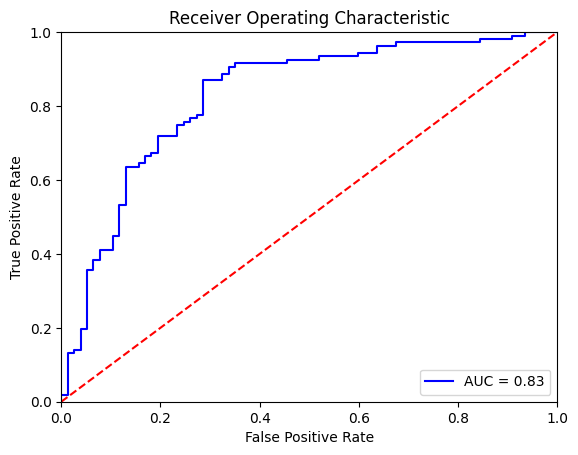

In [15]:
from transformers import BertForSequenceClassification
from transformers import DataCollatorWithPadding
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from sklearn.metrics import roc_curve, auc
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import sklearn.metrics as metrics

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to('mps')

model.dropout.p = 0

for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=00,
    learning_rate = 0.1,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

def find_best_threshold(y_true, y_pred):
    best_threshold = 0.0
    best_f1 = 0.0
    best_accuracy = 0.0
    
    thresholds = np.arange(0.0, 1.01, 0.01)
    for threshold in thresholds:
        y_pred_binary = (y_pred >= threshold).astype(int)
        
        current_f1 = f1_score(y_true, y_pred_binary)
        
        if current_f1 > best_f1:
            best_f1 = current_f1
            best_threshold = threshold
            best_accuracy = accuracy_score(y_true, y_pred_binary)
    
    return best_f1, best_threshold

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

  0%|          | 0/240 [00:00<?, ?it/s]

/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'loss': 0.5757, 'grad_norm': 8.468268394470215, 'learning_rate': 2.0000000000000002e-07, 'epoch': 0.83}


  0%|          | 0/3 [00:00<?, ?it/s]

{'eval_loss': 0.5367312431335449, 'eval_roc_auc': 0.8272848646680422, 'eval_runtime': 2.8738, 'eval_samples_per_second': 64.027, 'eval_steps_per_second': 1.044, 'epoch': 1.0}


...

  0%|          | 0/3 [00:00<?, ?it/s]

test f1 0.8490566037735849
test precision 0.8571428571428571
test recall 0.8411214953271028
test accuracy 0.8260869565217391
test roc_auc 0.8912489379779098



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/12 [00:00<?, ?it/s]

train f1 0.8729792147806005
train precision 0.8129032258064516
train recall 0.942643391521197
train accuracy 0.8501362397820164
train roc_auc 0.932443665610748


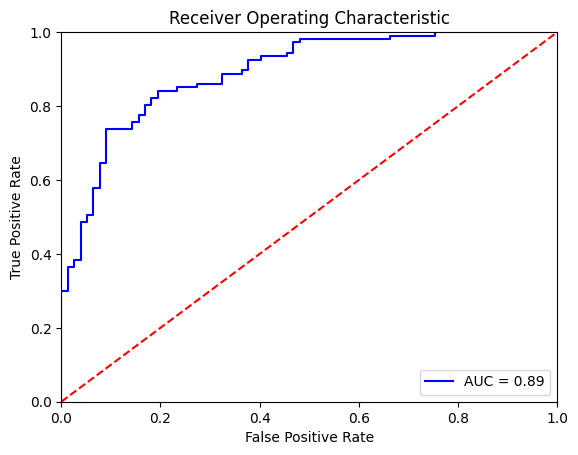

In [16]:
for param in model.bert.parameters():
    param.requires_grad = True

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    learning_rate = 0.00001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [17]:
from sklearn.utils import resample
from sklearn.metrics import roc_auc_score

scores = []
n_iter = 1000
multi = False
y_pred = (pred[0][:, 1] >= thr).astype(int)
for i in range(n_iter):
    y_true_boot, y_pred_boot, y_prob_boot = resample(y_test, y_pred, pred[0][:, 1], random_state=i+1)
    try:
        if multi:
            auc = roc_auc_score(y_true_boot, y_prob_boot, multi_class="ovr", average="macro")
            f1 = f1_score(y_true_boot, y_pred_boot, average="macro")
            pr = precision_score(y_true_boot, y_pred_boot, average="macro", zero_division=0)
            rc = recall_score (y_true_boot, y_pred_boot, average="macro", zero_division=0)
        else:
            auc = roc_auc_score(y_true_boot, y_prob_boot)
            f1  = f1_score(y_true_boot, y_pred_boot)
            pr  = precision_score(y_true_boot, y_pred_boot, zero_division=0)
            rc  = recall_score (y_true_boot, y_pred_boot, zero_division=0)
        scores.append((auc, f1, accuracy_score(y_true_boot, y_pred_boot), pr, rc))
    except ValueError:
        continue
scores = np.asarray(scores)
means, stds = scores.mean(0), scores.std(0, ddof=1)
names = ["ROC-AUC", "F1", "Accuracy", "Precision", "Recall"]
{n: f"{m:.4f}±{s:.4f}" for n, m, s in zip(names, means, stds)}

{'ROC-AUC': '0.8918±0.0240',
 'F1': '0.8498±0.0261',
 'Accuracy': '0.8274±0.0275',
 'Precision': '0.8567±0.0345',
 'Recall': '0.8442±0.0349'}

Map:   0%|          | 0/734 [00:00<?, ? examples/s]

Map:   0%|          | 0/184 [00:00<?, ? examples/s]

Map:   0%|          | 0/734 [00:00<?, ? examples/s]

Map:   0%|          | 0/184 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

  0%|          | 0/3 [00:00<?, ?it/s]

test f1 0.777292576419214
test precision 0.7295081967213115
test recall 0.8317757009345794
test accuracy 0.7228260869565217
test roc_auc 0.7725452117975483



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/12 [00:00<?, ?it/s]

train f1 0.7568181818181818
train precision 0.6951983298538622
train recall 0.830423940149626
train accuracy 0.7084468664850136
train roc_auc 0.7717006283091071


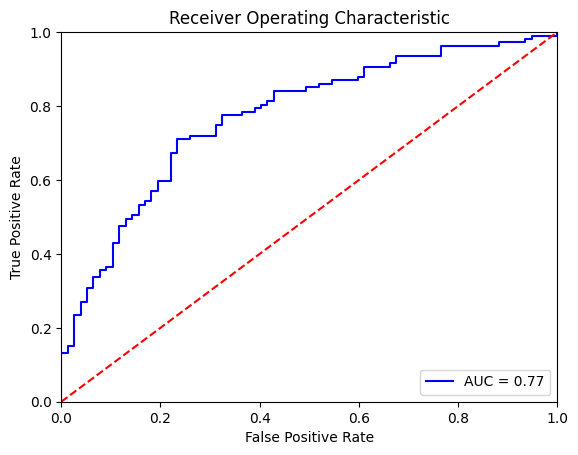

In [18]:
DROP_P = 0.5

X_train, X_test, y_train, y_test = train_test_split(df.drop('HeartDisease', axis =1),
                                                    df['HeartDisease'],
                                                    test_size=.2,
                                                    random_state = 42)
# y_train = y_train.replace({1:1, 2:0})
# y_test = y_test.replace({1:1, 2:0})

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

X_train['label'] = y_train
X_test['label'] = y_test

train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to('mps')

model.dropout.p = 0

for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=00,
    learning_rate = 0.1,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

  0%|          | 0/240 [00:00<?, ?it/s]

/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'loss': 0.626, 'grad_norm': 7.982761383056641, 'learning_rate': 2.0000000000000002e-07, 'epoch': 0.83}


  0%|          | 0/3 [00:00<?, ?it/s]

{'eval_loss': 0.603992760181427, 'eval_roc_auc': 0.777521543876684, 'eval_runtime': 2.9188, 'eval_samples_per_second': 63.04, 'eval_steps_per_second': 1.028, 'epoch': 1.0}


...

  0%|          | 0/3 [00:00<?, ?it/s]

test f1 0.8325358851674641
test precision 0.8529411764705882
test recall 0.8130841121495327
test accuracy 0.8097826086956522
test roc_auc 0.8539871343609661



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/12 [00:00<?, ?it/s]

train f1 0.8125
train precision 0.7842227378190255
train recall 0.8428927680798005
train accuracy 0.7874659400544959
train roc_auc 0.8776594549661881


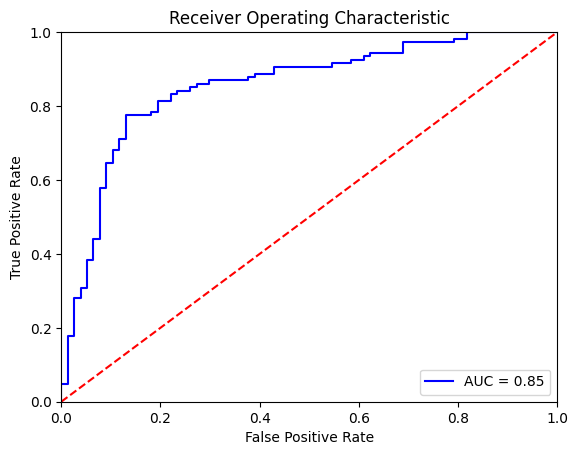

In [19]:
for param in model.bert.parameters():
    param.requires_grad = True

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    learning_rate = 0.00001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [20]:
scores = []
n_iter = 1000
multi = False
y_pred = (pred[0][:, 1] >= thr).astype(int)
for i in range(n_iter):
    y_true_boot, y_pred_boot, y_prob_boot = resample(y_test, y_pred, pred[0][:, 1], random_state=i+1)
    try:
        if multi:
            auc = roc_auc_score(y_true_boot, y_prob_boot, multi_class="ovr", average="macro")
            f1 = f1_score(y_true_boot, y_pred_boot, average="macro")
            pr = precision_score(y_true_boot, y_pred_boot, average="macro", zero_division=0)
            rc = recall_score (y_true_boot, y_pred_boot, average="macro", zero_division=0)
        else:
            auc = roc_auc_score(y_true_boot, y_prob_boot)
            f1  = f1_score(y_true_boot, y_pred_boot)
            pr  = precision_score(y_true_boot, y_pred_boot, zero_division=0)
            rc  = recall_score (y_true_boot, y_pred_boot, zero_division=0)
        scores.append((auc, f1, accuracy_score(y_true_boot, y_pred_boot), pr, rc))
    except ValueError:
        continue
scores = np.asarray(scores)
means, stds = scores.mean(0), scores.std(0, ddof=1)
names = ["ROC-AUC", "F1", "Accuracy", "Precision", "Recall"]
{n: f"{m:.4f}±{s:.4f}" for n, m, s in zip(names, means, stds)}

{'ROC-AUC': '0.8531±0.0291',
 'F1': '0.8312±0.0281',
 'Accuracy': '0.8091±0.0283',
 'Precision': '0.8515±0.0350',
 'Recall': '0.8131±0.0371'}

Map:   0%|          | 0/734 [00:00<?, ? examples/s]

Map:   0%|          | 0/184 [00:00<?, ? examples/s]

Map:   0%|          | 0/734 [00:00<?, ? examples/s]

Map:   0%|          | 0/184 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

  0%|          | 0/3 [00:00<?, ?it/s]

test f1 0.7353951890034365
test precision 0.5815217391304348
test recall 1.0
test accuracy 0.5815217391304348
test roc_auc 0.5140186915887851



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/12 [00:00<?, ?it/s]

train f1 0.375
train precision 0.6171428571428571
train recall 0.26932668329177056
train accuracy 0.5095367847411444
train roc_auc 0.5389379404341997


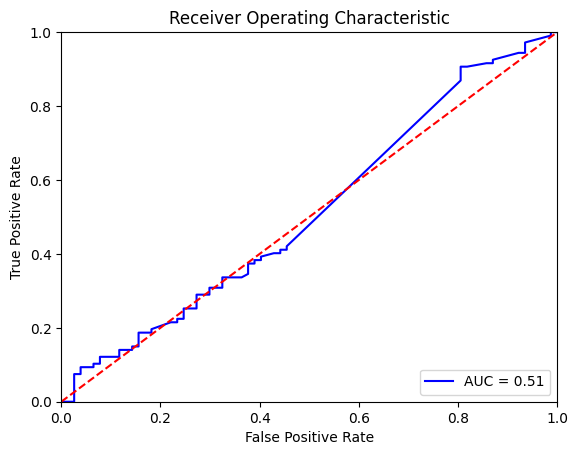

In [21]:
DROP_P = 0.9

X_train, X_test, y_train, y_test = train_test_split(df.drop('HeartDisease', axis =1),
                                                    df['HeartDisease'],
                                                    test_size=.2,
                                                    random_state = 42)
# y_train = y_train.replace({1:1, 2:0})
# y_test = y_test.replace({1:1, 2:0})

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

X_train['label'] = y_train
X_test['label'] = y_test

train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to('mps')

model.dropout.p = 0

for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=00,
    learning_rate = 0.1,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

  0%|          | 0/240 [00:00<?, ?it/s]

/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'loss': 0.6837, 'grad_norm': 6.73545503616333, 'learning_rate': 2.0000000000000002e-07, 'epoch': 0.83}


  0%|          | 0/3 [00:00<?, ?it/s]

{'eval_loss': 0.6889619827270508, 'eval_roc_auc': 0.511591212525792, 'eval_runtime': 1.4368, 'eval_samples_per_second': 128.061, 'eval_steps_per_second': 2.088, 'epoch': 1.0}


...

  0%|          | 0/3 [00:00<?, ?it/s]

test f1 0.7402135231316725
test precision 0.5977011494252874
test recall 0.9719626168224299
test accuracy 0.6032608695652174
test roc_auc 0.5550430877533681



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/12 [00:00<?, ?it/s]

train f1 0.7138863000931966
train precision 0.5699404761904762
train recall 0.9551122194513716
train accuracy 0.5817438692098093
train roc_auc 0.6459451970673916


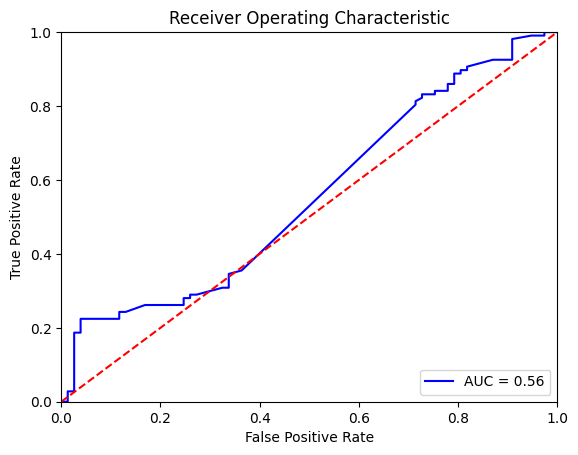

In [22]:
for param in model.bert.parameters():
    param.requires_grad = True

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    learning_rate = 0.00001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [23]:
scores = []
n_iter = 1000
multi = False
y_pred = (pred[0][:, 1] >= thr).astype(int)
for i in range(n_iter):
    y_true_boot, y_pred_boot, y_prob_boot = resample(y_test, y_pred, pred[0][:, 1], random_state=i+1)
    try:
        if multi:
            auc = roc_auc_score(y_true_boot, y_prob_boot, multi_class="ovr", average="macro")
            f1 = f1_score(y_true_boot, y_pred_boot, average="macro")
            pr = precision_score(y_true_boot, y_pred_boot, average="macro", zero_division=0)
            rc = recall_score (y_true_boot, y_pred_boot, average="macro", zero_division=0)
        else:
            auc = roc_auc_score(y_true_boot, y_prob_boot)
            f1  = f1_score(y_true_boot, y_pred_boot)
            pr  = precision_score(y_true_boot, y_pred_boot, zero_division=0)
            rc  = recall_score (y_true_boot, y_pred_boot, zero_division=0)
        scores.append((auc, f1, accuracy_score(y_true_boot, y_pred_boot), pr, rc))
    except ValueError:
        continue
scores = np.asarray(scores)
means, stds = scores.mean(0), scores.std(0, ddof=1)
names = ["ROC-AUC", "F1", "Accuracy", "Precision", "Recall"]
{n: f"{m:.4f}±{s:.4f}" for n, m, s in zip(names, means, stds)}

{'ROC-AUC': '0.5551±0.0413',
 'F1': '0.7390±0.0297',
 'Accuracy': '0.6026±0.0362',
 'Precision': '0.5970±0.0373',
 'Recall': '0.9718±0.0158'}

Map:   0%|          | 0/734 [00:00<?, ? examples/s]

Map:   0%|          | 0/184 [00:00<?, ? examples/s]

Map:   0%|          | 0/734 [00:00<?, ? examples/s]

Map:   0%|          | 0/184 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

  0%|          | 0/3 [00:00<?, ?it/s]

test f1 0.8544600938967136
test precision 0.8584905660377359
test recall 0.8504672897196262
test accuracy 0.8315217391304348
test roc_auc 0.8791115426629446



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/12 [00:00<?, ?it/s]

train f1 0.8456057007125891
train precision 0.8072562358276644
train recall 0.8877805486284289
train accuracy 0.8228882833787466
train roc_auc 0.8678304239401498


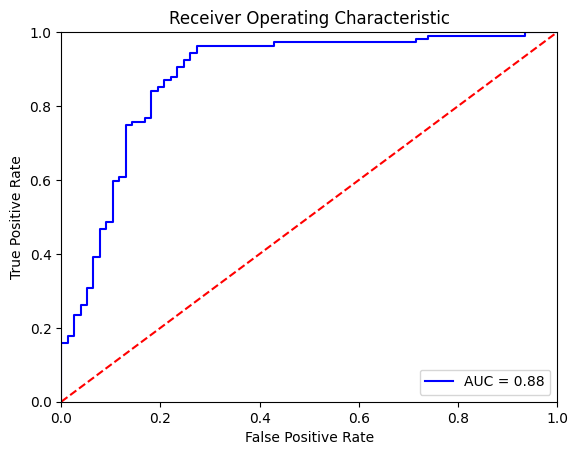

In [24]:
DROP_P = 0

X_train, X_test, y_train, y_test = train_test_split(df.drop('HeartDisease', axis =1),
                                                    df['HeartDisease'],
                                                    test_size=.2,
                                                    random_state = 42)
# y_train = y_train.replace({1:1, 2:0})
# y_test = y_test.replace({1:1, 2:0})

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

X_train['label'] = y_train
X_test['label'] = y_test

train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to('mps')

model.dropout.p = 0

for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=00,
    learning_rate = 0.1,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

  0%|          | 0/240 [00:00<?, ?it/s]

/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'loss': 0.5063, 'grad_norm': 8.661415100097656, 'learning_rate': 2.0000000000000002e-07, 'epoch': 0.83}


  0%|          | 0/3 [00:00<?, ?it/s]

{'eval_loss': 0.44744738936424255, 'eval_roc_auc': 0.8808107780070398, 'eval_runtime': 1.4337, 'eval_samples_per_second': 128.342, 'eval_steps_per_second': 2.093, 'epoch': 1.0}


...

  0%|          | 0/3 [00:00<?, ?it/s]

test f1 0.897196261682243
test precision 0.897196261682243
test recall 0.897196261682243
test accuracy 0.8804347826086957
test roc_auc 0.935793178783833



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/12 [00:00<?, ?it/s]

train f1 0.8907766990291263
train precision 0.8676122931442081
train recall 0.9152119700748129
train accuracy 0.8773841961852861
train roc_auc 0.9415500288318243


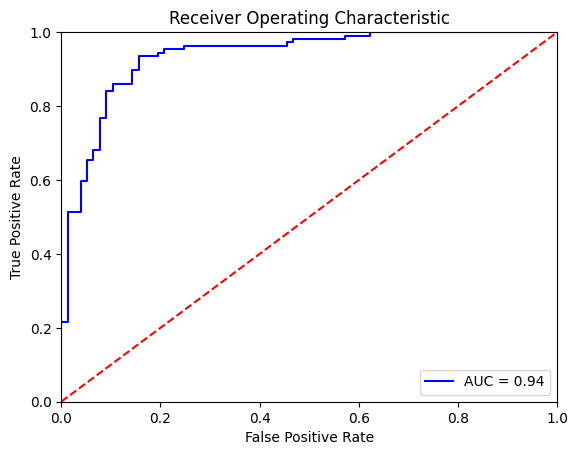

In [25]:
for param in model.bert.parameters():
    param.requires_grad = True

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    learning_rate = 0.00001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [26]:
scores = []
n_iter = 1000
multi = False
y_pred = (pred[0][:, 1] >= thr).astype(int)
for i in range(n_iter):
    y_true_boot, y_pred_boot, y_prob_boot = resample(y_test, y_pred, pred[0][:, 1], random_state=i+1)
    try:
        if multi:
            auc = roc_auc_score(y_true_boot, y_prob_boot, multi_class="ovr", average="macro")
            f1 = f1_score(y_true_boot, y_pred_boot, average="macro")
            pr = precision_score(y_true_boot, y_pred_boot, average="macro", zero_division=0)
            rc = recall_score (y_true_boot, y_pred_boot, average="macro", zero_division=0)
        else:
            auc = roc_auc_score(y_true_boot, y_prob_boot)
            f1  = f1_score(y_true_boot, y_pred_boot)
            pr  = precision_score(y_true_boot, y_pred_boot, zero_division=0)
            rc  = recall_score (y_true_boot, y_pred_boot, zero_division=0)
        scores.append((auc, f1, accuracy_score(y_true_boot, y_pred_boot), pr, rc))
    except ValueError:
        continue
scores = np.asarray(scores)
means, stds = scores.mean(0), scores.std(0, ddof=1)
names = ["ROC-AUC", "F1", "Accuracy", "Precision", "Recall"]
{n: f"{m:.4f}±{s:.4f}" for n, m, s in zip(names, means, stds)}

{'ROC-AUC': '0.9356±0.0185',
 'F1': '0.8967±0.0223',
 'Accuracy': '0.8803±0.0241',
 'Precision': '0.8958±0.0301',
 'Recall': '0.8985±0.0288'}